In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.features.extract import load_feature_config, extract_features_from_flows, feature_config_hash_text
from src.pipeline.feature_pipeline import FeaturePipeline
from src.pipeline.artifacts import default_feature_artifacts
from src.models.train_balanced_bagging_ensemble import run_balanced_bagging
from src.splits.io import load_splits

import sklearn.metrics as skm
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support, confusion_matrix

from src.eval.plots import (
    plot_roc_curves,
    plot_pr_curves,
    plot_confusion_matrices,
    plot_probability_distributions,
)

paths = load_paths()
logger = setup_logger(level="INFO")

features_yaml = paths.configs_dir / "features.yaml"
cfg = load_feature_config(features_yaml)

In [2]:
def apply_split_lists(df: pd.DataFrame, train_list: Path, val_list: Path, test_list: Path, *, split_col: str = "split") -> pd.DataFrame:
    splits = load_splits(train_list, val_list, test_list)

    cap_to_split = {}
    for split_name, caps in splits.items():
        for cid in caps:
            cap_to_split[str(cid)] = split_name

    out = df.copy()
    out["capture_id"] = out["capture_id"].astype(str)
    out[split_col] = out["capture_id"].map(cap_to_split)

    missing_caps = sorted(out.loc[out[split_col].isna(), "capture_id"].unique().tolist())
    if missing_caps:
        raise ValueError(
            f"Found {len(missing_caps)} captures without split assignment. "
            f"Examples: {missing_caps[:10]}"
        )

    return out


def print_split_summary(df: pd.DataFrame, name: str):
    print(f"\n{name} split counts:")
    print(df["split"].value_counts(dropna=False))
    print(f"\n{name} label by split:")
    print(pd.crosstab(df["split"], df["label"]))


def print_capture_summary(df: pd.DataFrame, name: str):
    tmp = (
        df.groupby(["split", "dataset"])["capture_id"]
        .nunique()
        .unstack(fill_value=0)
    )
    print(f"\n{name} unique captures by split/dataset:")
    print(tmp)

In [3]:
logger.info("Re-extracting VNAT features...")
vnat_flows = pd.read_parquet(paths.data_processed / "vnat" / "flows.parquet")
vnat_feats = extract_features_from_flows(vnat_flows, cfg)
vnat_feats["dataset"] = "vnat"

if "q_min_packets_ok" in vnat_feats.columns:
    vnat_feats = vnat_feats[vnat_feats["q_min_packets_ok"] == 1.0].copy()

vnat_feats = apply_split_lists(
    vnat_feats,
    paths.data_splits / "vnat_train_captures.txt",
    paths.data_splits / "vnat_val_captures.txt",
    paths.data_splits / "vnat_test_captures.txt",
)

print_split_summary(vnat_feats, "VNAT")
print_capture_summary(vnat_feats, "VNAT")

2026-03-26 12:05:11 | INFO | ai-vpn-firewall | Re-extracting VNAT features...

VNAT split counts:
split
train    7750
test      210
val       147
Name: count, dtype: int64

VNAT label by split:
label     0    1
split           
test    197   13
train  7401  349
val     135   12

VNAT unique captures by split/dataset:
dataset  vnat
split        
test       26
train     115
val        24


In [4]:
logger.info("Re-extracting ISCX features...")
iscx_flows = pd.read_parquet(paths.data_processed / "iscx" / "flows.parquet")
iscx_feats = extract_features_from_flows(iscx_flows, cfg)
iscx_feats["dataset"] = "iscx"

if "q_min_packets_ok" in iscx_feats.columns:
    iscx_feats = iscx_feats[iscx_feats["q_min_packets_ok"] == 1.0].copy()

iscx_feats = apply_split_lists(
    iscx_feats,
    paths.data_splits / "iscx_train_captures.txt",
    paths.data_splits / "iscx_val_captures.txt",
    paths.data_splits / "iscx_test_captures.txt",
)

print_split_summary(iscx_feats, "ISCX")
print_capture_summary(iscx_feats, "ISCX")

2026-03-26 12:05:39 | INFO | ai-vpn-firewall | Re-extracting ISCX features...

ISCX split counts:
split
train    8388
val      1779
test     1634
Name: count, dtype: int64

ISCX label by split:
label     0     1
split            
test   1396   238
train  6359  2029
val    1103   676

ISCX unique captures by split/dataset:
dataset  iscx
split        
test       21
train      98
val        21


In [6]:
logger.info("Loading USBVPN pre-extracted features...")
usbvpn_feats = pd.read_parquet(paths.data_processed / "usbvpn" / "flows.parquet")
usbvpn_feats["dataset"] = "usbvpn"

# The split is already in the parquet file for usbvpn
print_split_summary(usbvpn_feats, "USBVPN")
print_capture_summary(usbvpn_feats, "USBVPN")

2026-03-26 12:10:43 | INFO | ai-vpn-firewall | Loading USBVPN pre-extracted features...

USBVPN split counts:
split
train    41833
test      9002
val       8142
Name: count, dtype: int64

USBVPN label by split:
label      0     1
split             
test    7643  1359
train  35076  6757
val     7472   670

USBVPN unique captures by split/dataset:
dataset  usbvpn
split          
test         77
train       352
val          75


In [7]:
df_all = pd.concat([vnat_feats, iscx_feats, usbvpn_feats], ignore_index=True)

df_all["split"] = df_all["split"].astype(str)

valid_splits = {"train", "val", "test"}
bad_splits = sorted(set(df_all["split"].unique()) - valid_splits)
if bad_splits:
    raise ValueError(f"Unexpected split values found: {bad_splits}")

print("\nFINAL combined split counts:")
print(df_all["split"].value_counts())

print("\nFINAL combined label by split:")
print(pd.crosstab(df_all["split"], df_all["label"]))

print("\nFINAL combined dataset by split:")
print(pd.crosstab(df_all["split"], df_all["dataset"]))

print("\nFINAL combined unique captures by split/dataset:")
print(
    df_all.groupby(["split", "dataset"])["capture_id"]
    .nunique()
    .unstack(fill_value=0)
)


FINAL combined split counts:
split
train    57971
test     10846
val      10068
Name: count, dtype: int64

FINAL combined label by split:
label      0     1
split             
test    9236  1610
train  48836  9135
val     8710  1358

FINAL combined dataset by split:
dataset  iscx  usbvpn  vnat
split                      
test     1634    9002   210
train    8388   41833  7750
val      1779    8142   147

FINAL combined unique captures by split/dataset:
dataset  iscx  usbvpn  vnat
split                      
test       21      77    26
train      98     352   115
val        21      75    24


In [8]:
logger.info("Fitting FeaturePipeline...")
pipeline = FeaturePipeline().fit(df_all[df_all["split"] == "train"])

feature_art = default_feature_artifacts(paths.artifacts_dir / "features")
pipeline.save(feature_art, feature_config_hash=feature_config_hash_text(features_yaml))

feature_cols = pipeline.model_feature_names()
logger.info(f"Pipeline saved. Model features: {len(feature_cols)}")
print("Model feature count:", len(feature_cols))
print("First 30 model features:", feature_cols[:30])

2026-03-26 12:12:00 | INFO | ai-vpn-firewall | Fitting FeaturePipeline...
2026-03-26 12:12:00 | INFO | ai-vpn-firewall | Pipeline saved. Model features: 38
Model feature count: 38
First 30 model features: ['sz_cv', 'sz_all_mean', 'sz_all_std', 'sz_all_p25', 'sz_all_median', 'sz_all_p75', 'sz_mean_max', 'sz_mean_min', 'sz_std_max', 'sz_std_min', 'iat_all_mean', 'iat_all_std', 'iat_all_p25', 'iat_all_median', 'iat_all_p75', 'iat_mean_max', 'iat_mean_min', 'iat_std_max', 'iat_std_min', 'h_size_all_00', 'h_size_all_01', 'h_size_all_02', 'h_size_all_03', 'h_size_all_04', 'h_size_all_05', 'h_size_all_06', 'h_iat_all_00', 'h_iat_all_01', 'h_iat_all_02', 'h_iat_all_03']


In [9]:
logger.info("Transforming features for training...")
df_transformed = pipeline.transform(df_all)

meta_cols = ["label", "split", "capture_id", "dataset", "flow_id"]
for col in meta_cols:
    df_transformed[col] = df_all[col].values

print("Transformed shape:", df_transformed.shape)
print(df_transformed["split"].value_counts())
print(pd.crosstab(df_transformed["split"], df_transformed["dataset"]))

2026-03-26 12:12:00 | INFO | ai-vpn-firewall | Transforming features for training...
Transformed shape: (78885, 45)
split
train    57971
test     10846
val      10068
Name: count, dtype: int64
dataset  iscx  usbvpn  vnat
split                      
test     1634    9002   210
train    8388   41833  7750
val      1779    8142   147


In [10]:
logger.info("Training XGBoost (Balanced Bagging)...")

results = run_balanced_bagging(
    df=df_transformed,
    label_col="label",
    group_col="capture_id",
    dataset_col="dataset",
    split_col="split",
    bags_per_family=3,
    majority_ratio=1.0,
    target_fprs="0.001,0.005,0.01",
    seed=42,
    output_dir=str(paths.artifacts_dir / "balanced_bagging_xgb"),
    model_types=["xgb"],
    feature_cols=feature_cols,
    weight_xgb=1.0,
    weight_lgbm=1.0,
    weight_cat=1.0,
)

2026-03-26 12:12:00 | INFO | ai-vpn-firewall | Training XGBoost (Balanced Bagging)...


In [11]:
print("\n" + "=" * 60)
print("XGBOOST EVALUATION (BALANCED BAGGING)")
print("=" * 60)

# Helper to print metrics for a specific mode (raw, isotonic, platt)
def print_mode_metrics(mode_name, results_dict):
    print(f"\n>>> MODE: {mode_name.upper()} <<<")

    if mode_name not in results_dict:
        print("  (No metrics found)")
        return

    mode_res = results_dict[mode_name]

    # Print Val and Test Overall
    for split_key in ["val", "test_overall"]:
        if split_key in mode_res:
            m = mode_res[split_key]
            print(f"\n  --- {split_key.upper()} ---")
            if "auc" in m and m["auc"] is not None:
                print(f"  ROC AUC: {m['auc']:.4f}")
            if "pr_auc" in m and m["pr_auc"] is not None:
                print(f"  PR AUC:  {m['pr_auc']:.4f}")

            # Print thresholds
            for key, val in m.items():
                if key.startswith("fpr_"):
                    print(f"    Policy: {key}")
                    print(f"      Threshold: {val['threshold']:.4f}")
                    print(f"      Recall:    {val['recall']:.4f}")
                    print(f"      Precision: {val['precision']:.4f}")
                    print(f"      FPR:       {val['fpr']:.5f}")

# Print for all 3 modes
for mode in ["raw", "isotonic", "platt"]:
    print_mode_metrics(mode, results)

print("\n" + "=" * 60)


XGBOOST EVALUATION (BALANCED BAGGING)

>>> MODE: RAW <<<

  --- VAL ---
  ROC AUC: 0.9966
  PR AUC:  0.9863
    Policy: fpr_0.0
      Threshold: 0.9894
      Recall:    0.7842
      Precision: 0.9991
      FPR:       0.00011
    Policy: fpr_0.001
      Threshold: 0.8898
      Recall:    0.9013
      Precision: 0.9927
      FPR:       0.00103
    Policy: fpr_0.005
      Threshold: 0.5728
      Recall:    0.9212
      Precision: 0.9660
      FPR:       0.00505
    Policy: fpr_0.01
      Threshold: 0.3235
      Recall:    0.9426
      Precision: 0.9357
      FPR:       0.01010

  --- TEST_OVERALL ---
  ROC AUC: 0.9967
  PR AUC:  0.9883
    Policy: fpr_0.0
      Threshold: 0.9894
      Recall:    0.8329
      Precision: 0.9978
      FPR:       0.00032
    Policy: fpr_0.001
      Threshold: 0.8898
      Recall:    0.8950
      Precision: 0.9877
      FPR:       0.00195
    Policy: fpr_0.005
      Threshold: 0.5728
      Recall:    0.9565
      Precision: 0.9667
      FPR:       0.00574
   


Predictions columns:
['capture_id', 'dataset', 'label', 'flow_id', 'p_xgb_raw', 'p_lgbm_raw', 'p_cat_raw', 'prob_raw', 'prob_iso', 'prob_platt', 'prob', 'split']

--- RAW vs CALIBRATED COMPARISON (XGBoost) ---

--- SPLIT: VAL ---
    Mode    AUC  PR_AUC  Brier  LogLoss
     Raw 0.9966  0.9863 0.0113   0.0417
Isotonic 0.9971  0.9844 0.0101   0.0362
   Platt 0.9966  0.9863 0.0125   0.0545

--- SPLIT: TEST ---
    Mode    AUC  PR_AUC  Brier  LogLoss
     Raw 0.9967  0.9883 0.0100   0.0405
Isotonic 0.9966  0.9837 0.0110   0.0429
   Platt 0.9967  0.9883 0.0101   0.0487

--- Generating Plots for XGBoost (Isotonic) ---


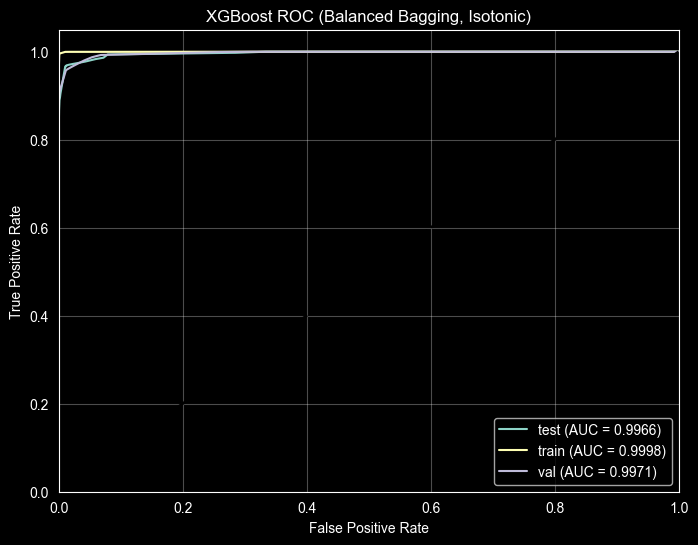

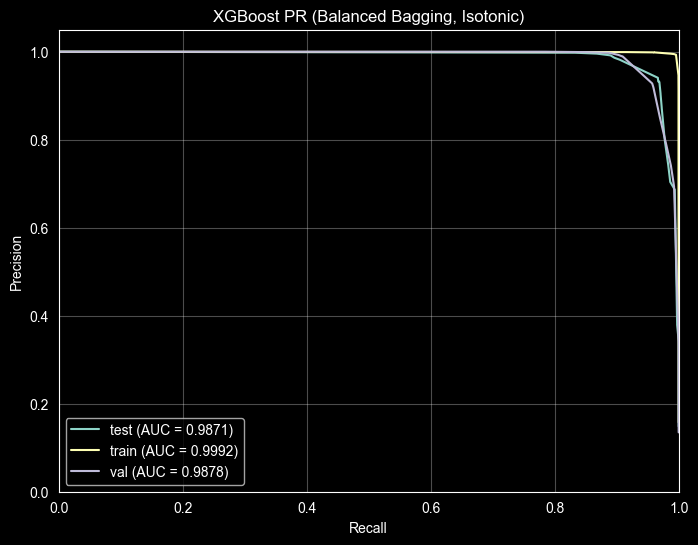

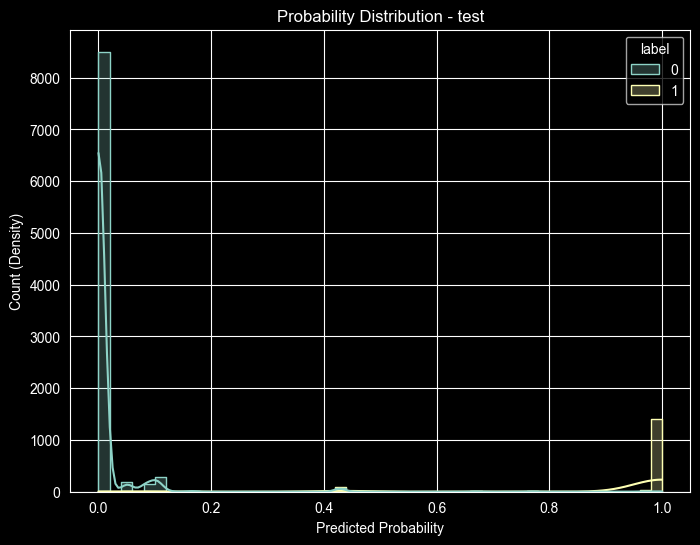

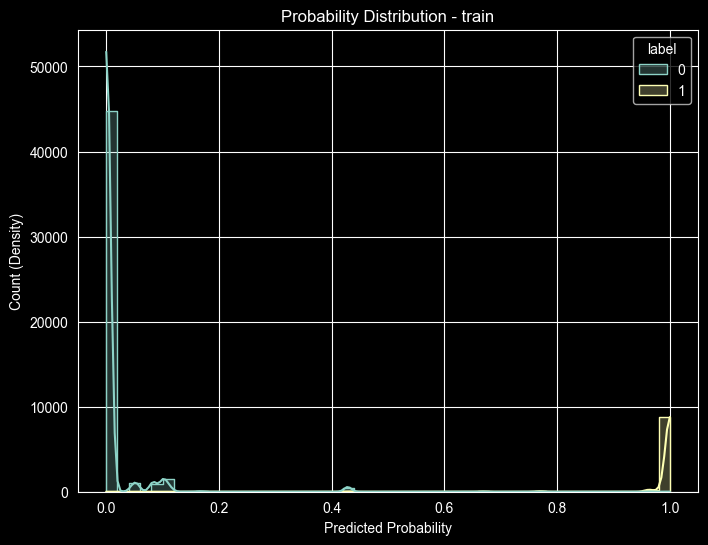

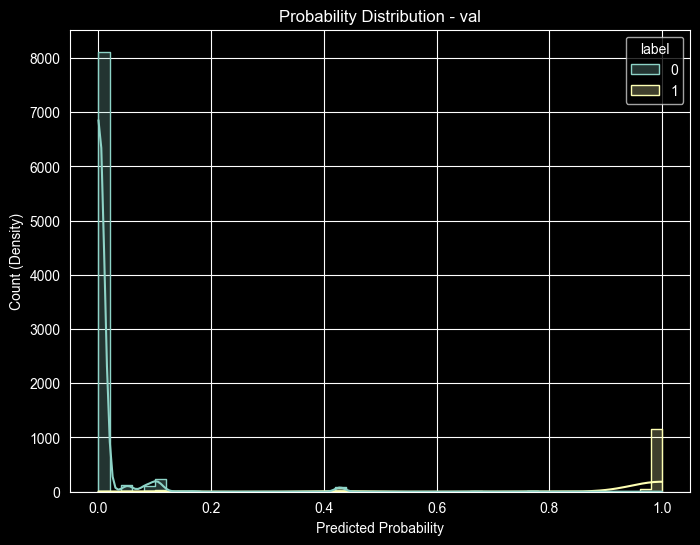


--- Confusion Matrices at Policy Thresholds (Test Set, Isotonic) ---


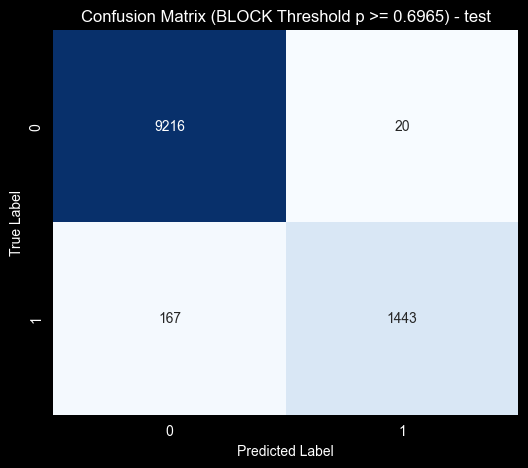

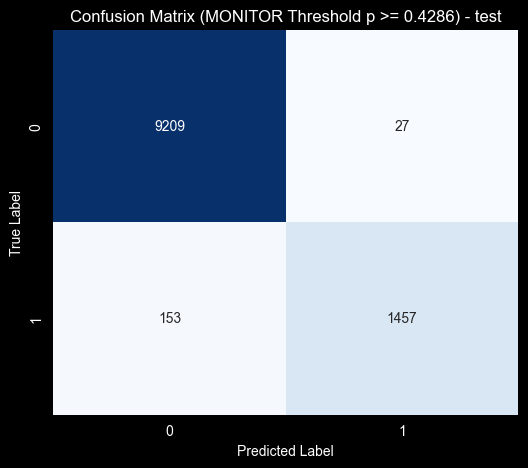

In [12]:
preds_path = paths.artifacts_dir / "balanced_bagging_xgb" / "predictions.csv"

if preds_path.exists():
    df_preds = pd.read_csv(preds_path)

    # Check for required columns
    required_cols = ["prob_raw", "prob_iso", "prob_platt"]
    missing = [c for c in required_cols if c not in df_preds.columns]
    if missing:
        raise ValueError(f"Missing probability columns in predictions.csv: {missing}")

    print("\nPredictions columns:")
    print(df_preds.columns.tolist())

    from sklearn.metrics import brier_score_loss, log_loss

    print("\n--- RAW vs CALIBRATED COMPARISON (XGBoost) ---")
    for split_name in ["val", "test"]:
        sub = df_preds[df_preds["split"] == split_name].copy()
        if sub.empty:
            continue

        y = sub["label"].astype(int)

        print(f"\n--- SPLIT: {split_name.upper()} ---")

        stats = []
        for mode, col in [("Raw", "prob_raw"), ("Isotonic", "prob_iso"), ("Platt", "prob_platt")]:
            p = sub[col]
            auc = roc_auc_score(y, p)
            ap = average_precision_score(y, p)
            brier = brier_score_loss(y, p)
            ll = log_loss(y, np.clip(p, 1e-6, 1 - 1e-6))

            stats.append({
                "Mode": mode,
                "AUC": auc,
                "PR_AUC": ap,
                "Brier": brier,
                "LogLoss": ll
            })

        print(pd.DataFrame(stats).to_string(index=False, float_format="%.4f"))

    print("\n--- Generating Plots for XGBoost (Isotonic) ---")
    plot_roc_curves(df_preds, prob_col="prob_iso", title="XGBoost ROC (Balanced Bagging, Isotonic)")
    plot_pr_curves(df_preds, prob_col="prob_iso", title="XGBoost PR (Balanced Bagging, Isotonic)")
    plot_probability_distributions(df_preds, prob_col="prob_iso")

    # Confusion Matrices for Isotonic
    val_metrics_iso = results.get("isotonic", {}).get("val", {})

    def get_thr(metrics_dict, fpr):
        key = f"fpr_{fpr}"
        if key in metrics_dict:
            return metrics_dict[key]["threshold"]
        return 0.99

    T_BLOCK = get_thr(val_metrics_iso, 0.001)
    T_MONITOR = get_thr(val_metrics_iso, 0.01)

    print("\n--- Confusion Matrices at Policy Thresholds (Test Set, Isotonic) ---")
    test_preds = df_preds[df_preds["split"] == "test"].copy()

    plot_confusion_matrices(
        test_preds,
        prob_col="prob_iso",
        threshold=T_BLOCK,
        title=f"Confusion Matrix (BLOCK Threshold p >= {T_BLOCK:.4f})"
    )

    plot_confusion_matrices(
        test_preds,
        prob_col="prob_iso",
        threshold=T_MONITOR,
        title=f"Confusion Matrix (MONITOR Threshold p >= {T_MONITOR:.4f})"
    )
else:
    print("Predictions file not found, skipping plots.")


--- Reliability Diagram (Test Set) ---


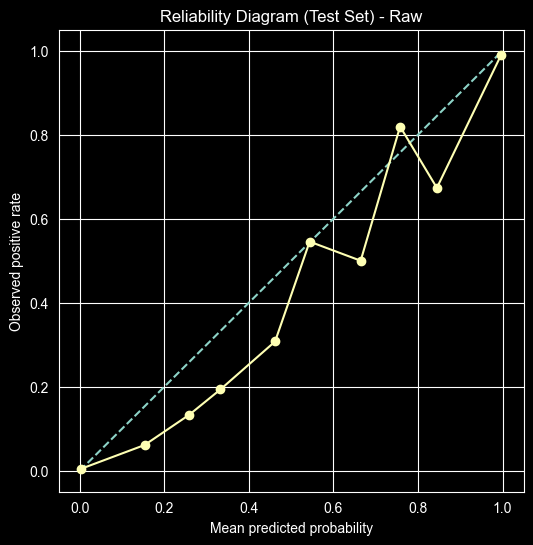

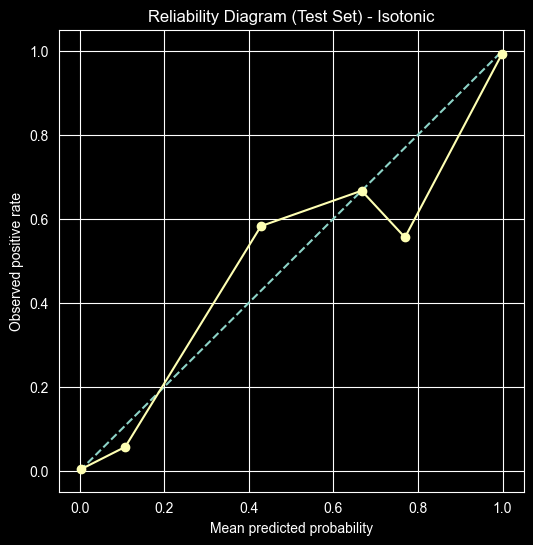

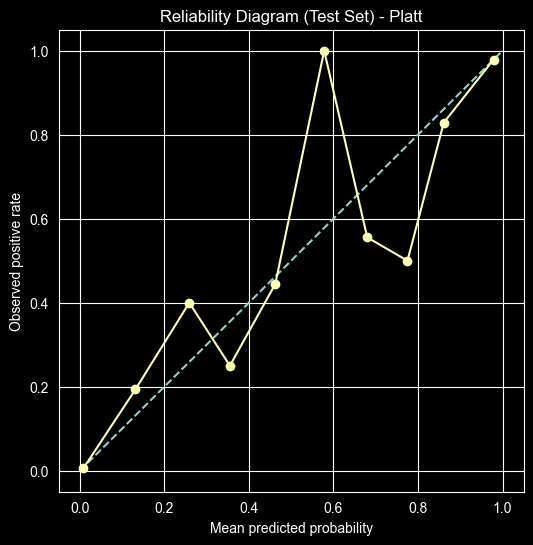

In [13]:
def plot_reliability_curve(y_true, y_prob, n_bins=10, title="Reliability Diagram"):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    pred_means = []
    obs_rates = []
    counts = []

    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue
        pred_means.append(y_prob[mask].mean())
        obs_rates.append(y_true[mask].mean())
        counts.append(mask.sum())

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.plot(pred_means, obs_rates, marker="o")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed positive rate")
    plt.title(title)
    plt.grid(True)
    plt.show()

    return pd.DataFrame({
        "bin_pred_mean": pred_means,
        "bin_obs_rate": obs_rates,
        "count": counts,
    })

if "df_preds" in locals():
    print("\n--- Reliability Diagram (Test Set) ---")
    test_preds = df_preds[df_preds["split"] == "test"]

    for mode, col in [("Raw", "prob_raw"), ("Isotonic", "prob_iso"), ("Platt", "prob_platt")]:
        plot_reliability_curve(
            test_preds["label"],
            test_preds[col],
            n_bins=10,
            title=f"Reliability Diagram (Test Set) - {mode}"
        )
else:
    print("df_preds not found. Run the previous cell to load predictions.")